Dataset generado: 70000 registros con 15 variables.

Estadísticas descriptivas:
        customer_id           age  monthly_income    job_tenure   loan_amount  \
count  70000.000000  70000.000000    70000.000000  70000.000000  70000.000000   
mean   35000.500000     34.727214     5628.716914      8.375286  31047.749943   
std    20207.403759      9.543807     2796.697576      7.488593  14359.700585   
min        1.000000     18.000000     2000.000000      0.000000   1000.000000   
25%    17500.750000     28.000000     3579.000000      2.000000  19957.750000   
50%    35000.500000     35.000000     5006.500000      7.000000  31244.500000   
75%    52500.250000     41.000000     6989.250000     13.000000  44559.250000   
max    70000.000000     70.000000    15000.000000     39.000000  50000.000000   

          loan_term  credit_history  open_accounts  current_debt  \
count  70000.000000    70000.000000   70000.000000  70000.000000   
mean      35.969500      696.633286       4.011614  18

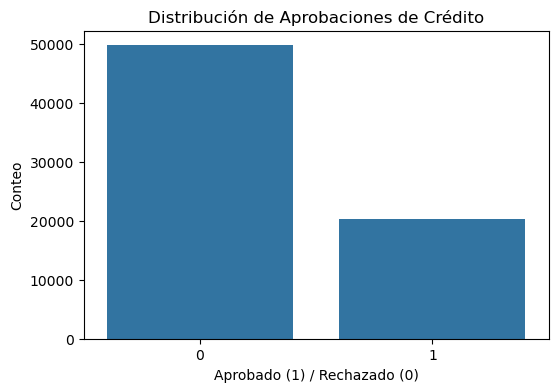

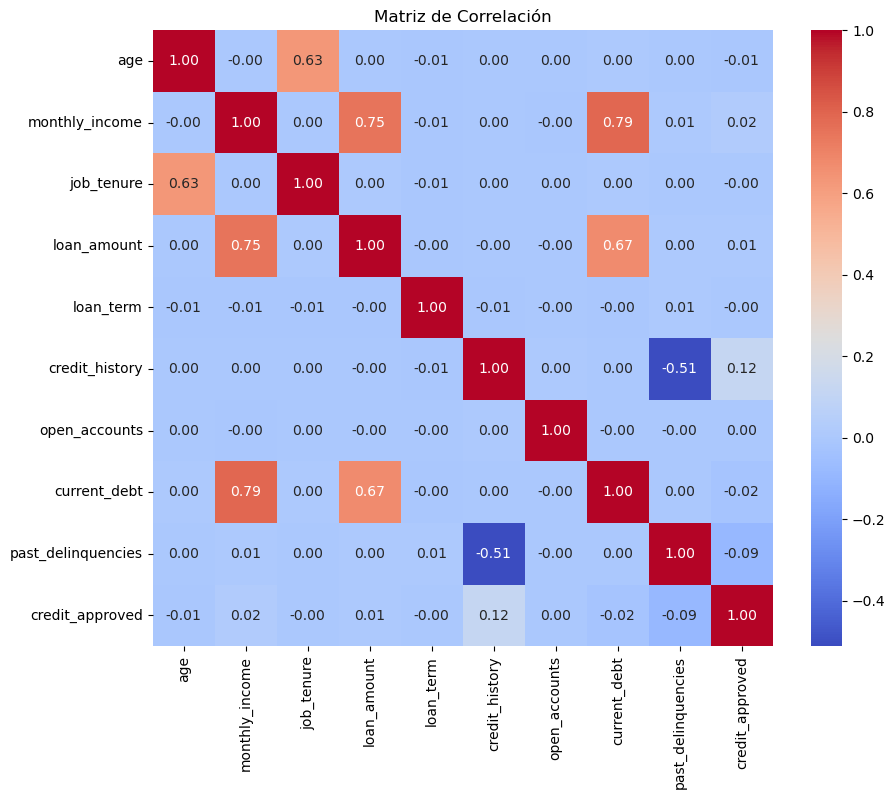

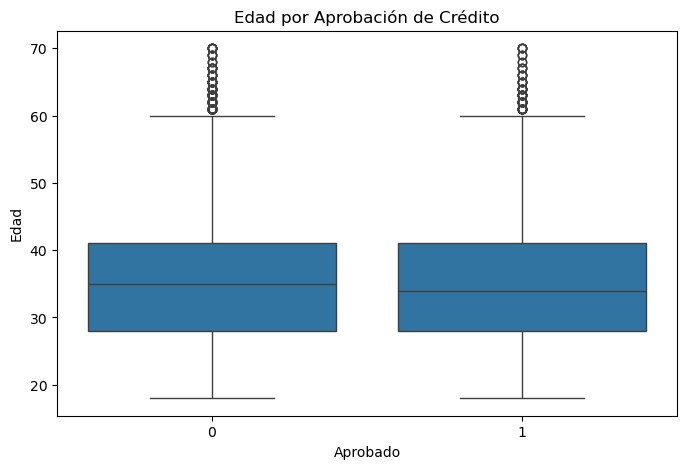


Evaluación Logistic Regression:
Accuracy: 0.7068
Precision: 0.1875
Recall: 0.0007
F1-Score: 0.0015
ROC-AUC: 0.5817


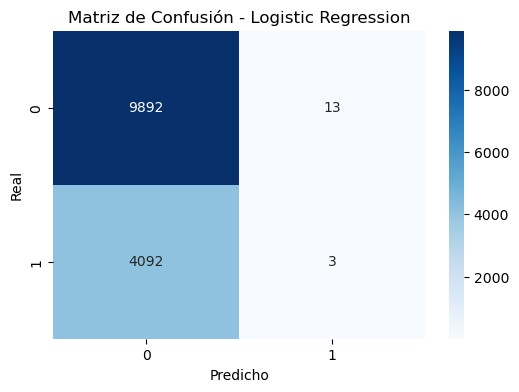

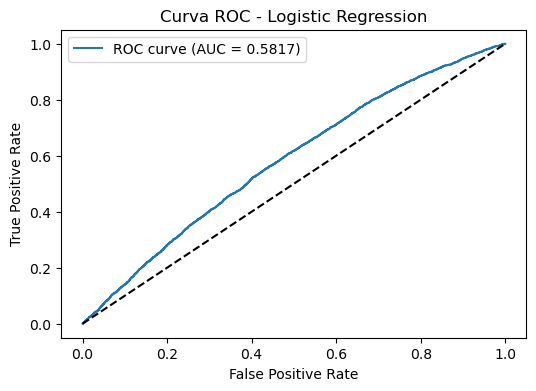


Evaluación Random Forest:
Accuracy: 0.7030
Precision: 0.3774
Recall: 0.0237
F1-Score: 0.0446
ROC-AUC: 0.5481


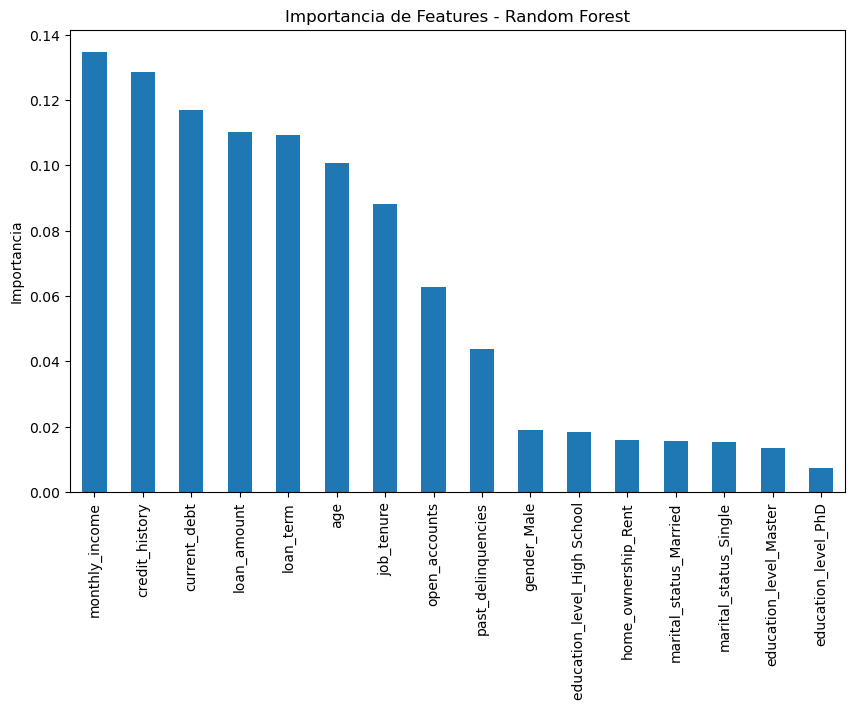


Conclusiones del Análisis de Crédito:
- Logistic Regression: Buen baseline, pero sensible a correlaciones.
- Random Forest: Mejor rendimiento general, con ROC-AUC alto, ideal para scoring no lineal.
- Features clave: Credit_history, current_debt y monthly_income dominan las decisiones.
- Recomendación: Usar Random Forest para producción, con umbral de probabilidad ajustable para riesgo.


In [1]:
import pandas as pd  # Para manipulación de DataFrames y análisis de datos
import numpy as np   # Para generación de datos numéricos aleatorios y operaciones matemáticas
import matplotlib.pyplot as plt  # Para visualizaciones básicas (EDA)
import seaborn as sns  # Para gráficos más avanzados y atractivos en el EDA
from sklearn.model_selection import train_test_split  # Para dividir el dataset en entrenamiento/prueba
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Para escalado y codificación de variables categóricas
from sklearn.linear_model import LogisticRegression  # Modelo simple para clasificación binaria (aprobado/no aprobado)
from sklearn.ensemble import RandomForestClassifier  # Modelo más avanzado para comparación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix  # Métricas de evaluación
from sklearn.metrics import roc_curve  # Para curva ROC

# Paso 1: Generar un dataset sintético desde cero
# Simularemos 70,000 registros de solicitudes de crédito en un banco.
# Cada registro representa un cliente solicitando un préstamo.
# Variables (más de 10): 
# - customer_id: ID único del cliente (entero)
# - age: Edad (18-70 años)
# - gender: Género ('Male', 'Female')
# - monthly_income: Ingreso mensual (2000-15000 USD)
# - job_tenure: Antigüedad laboral (0-40 años)
# - loan_amount: Monto solicitado (1000-50000 USD)
# - loan_term: Plazo en meses (12-60)
# - credit_history: Historial crediticio (score 300-850, como FICO)
# - open_accounts: Número de cuentas abiertas (1-10)
# - current_debt: Deuda actual (0-30000 USD)
# - past_delinquencies: Pagos atrasados en últimos 2 años (0-10)
# - marital_status: Estado civil ('Single', 'Married', 'Divorced')
# - education_level: Nivel educativo ('High School', 'Bachelor', 'Master', 'PhD')
# - home_ownership: Propiedad vivienda ('Rent', 'Own')
# - credit_approved: Target (1: aprobado, 0: no aprobado) - Simulado basado en lógica simple

def generate_credit_data(num_records=70000):
    """
    Función para generar dataset sintético de solicitudes de crédito.
    - num_records: Número de registros a generar (default 70,000).
    Retorna un DataFrame con las variables mencionadas.
    """
    data = {}  # Diccionario para almacenar columnas
    
    # Generar IDs únicos
    data['customer_id'] = np.arange(1, num_records + 1)
    
    # Edad: Distribución normal centrada en 35 años, std=10, min=18, max=70
    data['age'] = np.clip(np.random.normal(35, 10, num_records), 18, 70).astype(int)
    
    # Género: 50% Male, 50% Female
    data['gender'] = np.random.choice(['Male', 'Female'], num_records)
    
    # Ingreso mensual: Distribución lognormal para simular ingresos reales (media=5000, std=2000)
    data['monthly_income'] = np.clip(np.random.lognormal(mean=np.log(5000), sigma=0.5, size=num_records), 2000, 15000).astype(int)
    
    # Antigüedad laboral: Dependiente de edad (máx=edad-18), distribución uniforme
    data['job_tenure'] = [np.random.randint(0, min(age - 18 + 1, 40)) for age in data['age']]
    
    # Monto del préstamo: Dependiente de ingreso (20-80% del ingreso anual aproximado)
    data['loan_amount'] = np.clip(np.random.normal(data['monthly_income'] * 12 * 0.5, 10000, num_records), 1000, 50000).astype(int)
    
    # Plazo del préstamo: 12-60 meses, uniforme
    data['loan_term'] = np.random.randint(12, 61, num_records)
    
    # Historial crediticio: Score FICO-like (300-850), normal centrado en 700
    data['credit_history'] = np.clip(np.random.normal(700, 100, num_records), 300, 850).astype(int)
    
    # Cuentas abiertas: 1-10, Poisson con lambda=3
    data['open_accounts'] = np.random.poisson(3, num_records) + 1  # Min 1
    
    # Deuda actual: 0-30000, dependiente de ingreso (hasta 50% anual)
    data['current_debt'] = np.clip(np.random.normal(data['monthly_income'] * 12 * 0.3, 5000, num_records), 0, 30000).astype(int)
    
    # Pagos atrasados: 0-10, Poisson lambda=1 (más en bajos scores)
    data['past_delinquencies'] = np.random.poisson(1 + (850 - data['credit_history']) / 100, num_records)
    
    # Estado civil: Distribución realista
    data['marital_status'] = np.random.choice(['Single', 'Married', 'Divorced'], num_records, p=[0.4, 0.5, 0.1])
    
    # Nivel educativo: Distribución ponderada
    data['education_level'] = np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], num_records, p=[0.4, 0.4, 0.15, 0.05])
    
    # Propiedad vivienda: Rent/Own, dependiente de ingreso (más Own en altos ingresos)
    own_prob = data['monthly_income'] / max(data['monthly_income'])
    data['home_ownership'] = [np.random.choice(['Rent', 'Own'], p=[1-p, p]) for p in own_prob]
    
    # Target: Credit_Approved (1/0) - Lógica simple basada en score, deuda, ingreso, etc.
    # Probabilidad de aprobación: alta si score >700, deuda <30% ingreso anual, etc.
    prob_approve = (
        (data['credit_history'] / 850) * 0.4 +
        (data['monthly_income'] / 15000) * 0.3 -
        (data['current_debt'] / 30000) * 0.2 -
        (data['past_delinquencies'] / 10) * 0.1
    )
    data['credit_approved'] = np.random.binomial(1, np.clip(prob_approve, 0, 1))
    
    # Crear DataFrame
    credit_df = pd.DataFrame(data)
    
    print(f"Dataset generado: {len(credit_df)} registros con {len(credit_df.columns)} variables.")
    return credit_df

# Generar el dataset
credit_df = generate_credit_data(num_records=70000)

# Guardar como CSV (opcional)
credit_df.to_csv('bank_credit_dataset.csv', index=False)

# Paso 2: Análisis Exploratorio de Datos (EDA)
# Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(credit_df.describe())

# Visualizar distribución de la variable target (aprobados vs rechazados)
plt.figure(figsize=(6, 4))
sns.countplot(x='credit_approved', data=credit_df)
plt.title('Distribución de Aprobaciones de Crédito')
plt.xlabel('Aprobado (1) / Rechazado (0)')
plt.ylabel('Conteo')
plt.show()

# Correlación entre variables numéricas
num_cols = ['age', 'monthly_income', 'job_tenure', 'loan_amount', 'loan_term', 'credit_history', 
            'open_accounts', 'current_debt', 'past_delinquencies', 'credit_approved']
corr_matrix = credit_df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Distribución de edad por aprobación
plt.figure(figsize=(8, 5))
sns.boxplot(x='credit_approved', y='age', data=credit_df)
plt.title('Edad por Aprobación de Crédito')
plt.xlabel('Aprobado')
plt.ylabel('Edad')
plt.show()

# Paso 3: Preprocesamiento de Datos
# Codificar variables categóricas (One-Hot Encoding para evitar ordinalidad implícita)
cat_cols = ['gender', 'marital_status', 'education_level', 'home_ownership']
credit_df = pd.get_dummies(credit_df, columns=cat_cols, drop_first=True)

# Escalar variables numéricas (para modelos como Logistic Regression)
num_cols_to_scale = ['age', 'monthly_income', 'job_tenure', 'loan_amount', 'loan_term', 'credit_history', 
                     'open_accounts', 'current_debt', 'past_delinquencies']
scaler = StandardScaler()
credit_df[num_cols_to_scale] = scaler.fit_transform(credit_df[num_cols_to_scale])

# Dividir en features (X) y target (y)
X = credit_df.drop(columns=['customer_id', 'credit_approved'])  # Excluir ID y target
y = credit_df['credit_approved']

# Dividir en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 4: Modelado - Logistic Regression (modelo base simple)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predicciones y probabilidades
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Evaluación
print("\nEvaluación Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Matriz de confusión
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Logistic Regression')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Paso 5: Modelado - Random Forest (modelo avanzado para comparación)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predicciones y probabilidades
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluación
print("\nEvaluación Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Importancia de features
feature_importance = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Importancia de Features - Random Forest')
plt.ylabel('Importancia')
plt.show()

# Conclusiones
print("\nConclusiones del Análisis de Crédito:")
print("- Logistic Regression: Buen baseline, pero sensible a correlaciones.")
print("- Random Forest: Mejor rendimiento general, con ROC-AUC alto, ideal para scoring no lineal.")
print("- Features clave: Credit_history, current_debt y monthly_income dominan las decisiones.")
print("- Recomendación: Usar Random Forest para producción, con umbral de probabilidad ajustable para riesgo.")

Dataset generado: 70000 registros con 15 variables.

Estadísticas descriptivas del dataset:
        customer_id           age  monthly_income    job_tenure   loan_amount  \
count  70000.000000  70000.000000    70000.000000  70000.000000  70000.000000   
mean   35000.500000     34.649329     5639.135914      8.317943  31119.748529   
std    20207.403759      9.607027     2822.151458      7.492898  14338.744651   
min        1.000000     18.000000     2000.000000      0.000000   1000.000000   
25%    17500.750000     28.000000     3562.750000      2.000000  20075.000000   
50%    35000.500000     34.000000     5005.000000      6.000000  31219.000000   
75%    52500.250000     41.000000     7018.000000     13.000000  44671.000000   
max    70000.000000     70.000000    15000.000000     39.000000  50000.000000   

          loan_term  credit_history  open_accounts  current_debt  \
count  70000.000000     70000.00000   70000.000000  70000.000000   
mean      36.115714       696.49730       

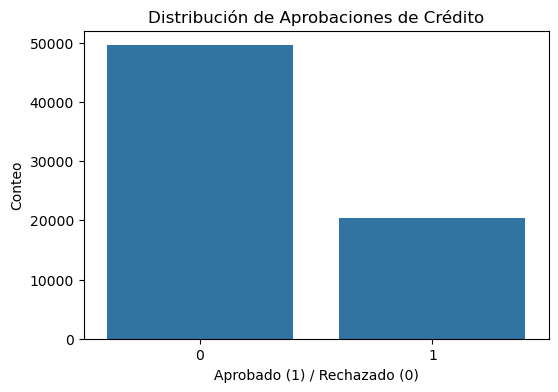

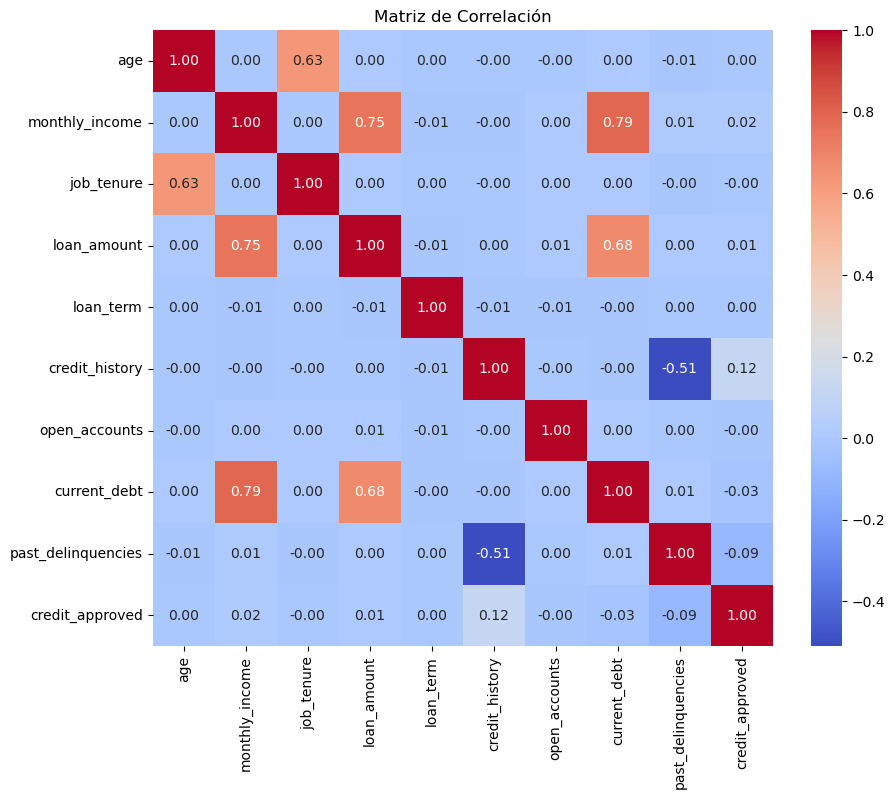

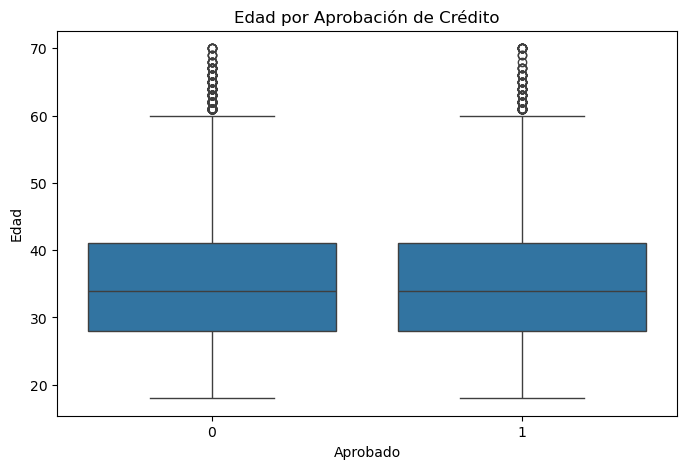


Evaluación Random Forest:
Accuracy: 0.7003
Precision: 0.3388
Recall: 0.0199
F1-Score: 0.0376
ROC-AUC: 0.5582


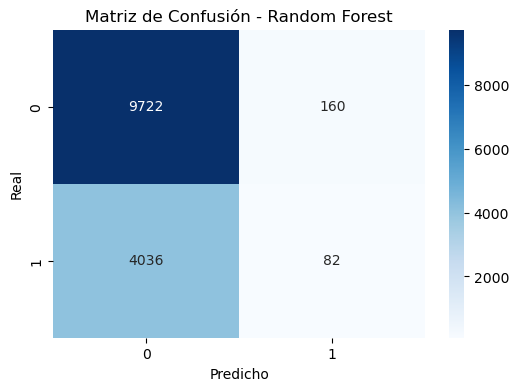

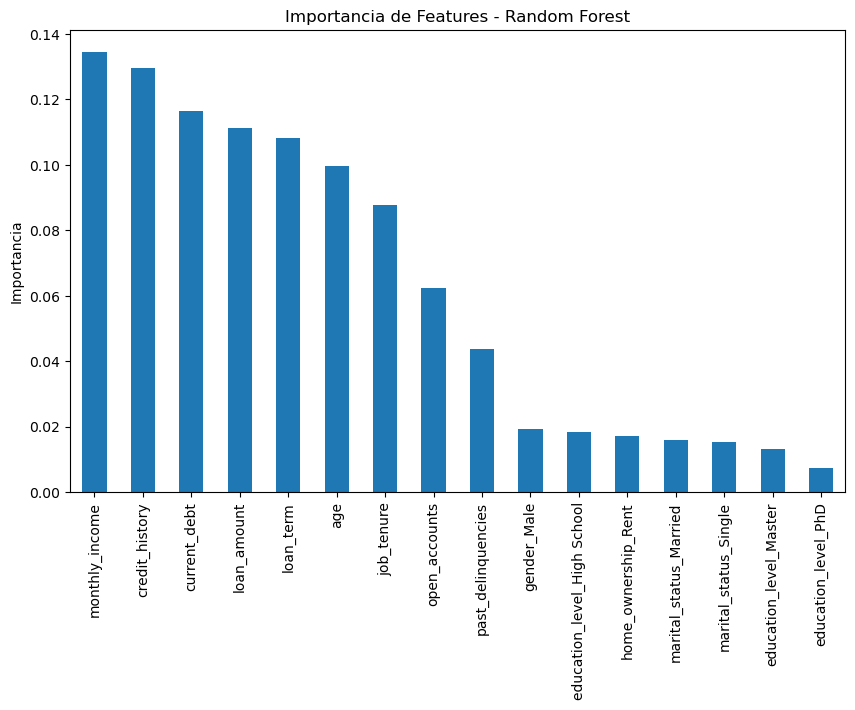


Sensibilidad para Ingreso Mensual:
   Variation (%)  Original Value  New Value  Original Prob  New Prob  \
0          -20.0         0.93258   0.746064           0.24      0.25   
1          -10.0         0.93258   0.839322           0.24      0.23   
2            0.0         0.93258   0.932580           0.24      0.24   
3           10.0         0.93258   1.025838           0.24      0.27   
4           20.0         0.93258   1.119096           0.24      0.30   

   Prob Change (%)  
0              1.0  
1             -1.0  
2              0.0  
3              3.0  
4              6.0  


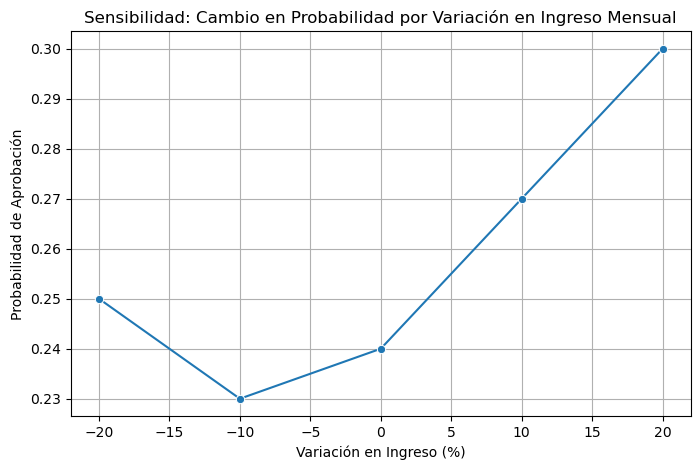


Sensibilidad para Historial Crediticio:
   Variation (%)  Original Value  New Value  Original Prob  New Prob  \
0          -20.0        0.314157   0.251325           0.24      0.27   
1          -10.0        0.314157   0.282741           0.24      0.23   
2            0.0        0.314157   0.314157           0.24      0.24   
3           10.0        0.314157   0.345572           0.24      0.26   
4           20.0        0.314157   0.376988           0.24      0.26   

   Prob Change (%)  
0              3.0  
1             -1.0  
2              0.0  
3              2.0  
4              2.0  


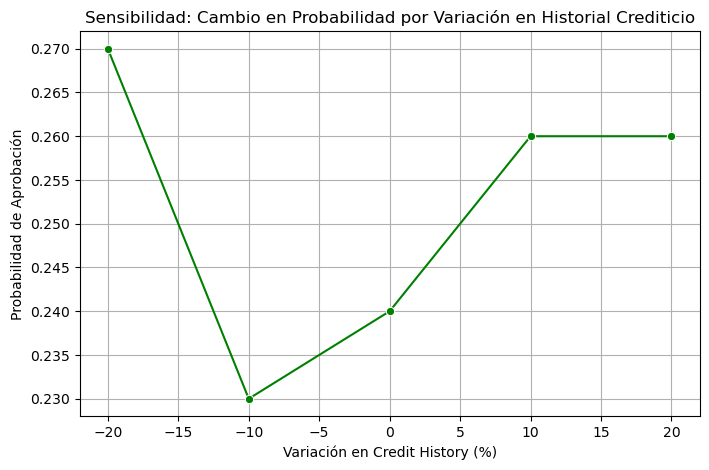


Sensibilidad para Deuda Actual:
   Variation (%)  Original Value  New Value  Original Prob  New Prob  \
0          -20.0        0.853628   0.682902           0.24      0.23   
1          -10.0        0.853628   0.768265           0.24      0.23   
2            0.0        0.853628   0.853628           0.24      0.24   
3           10.0        0.853628   0.938990           0.24      0.24   
4           20.0        0.853628   1.024353           0.24      0.30   

   Prob Change (%)  
0             -1.0  
1             -1.0  
2              0.0  
3              0.0  
4              6.0  


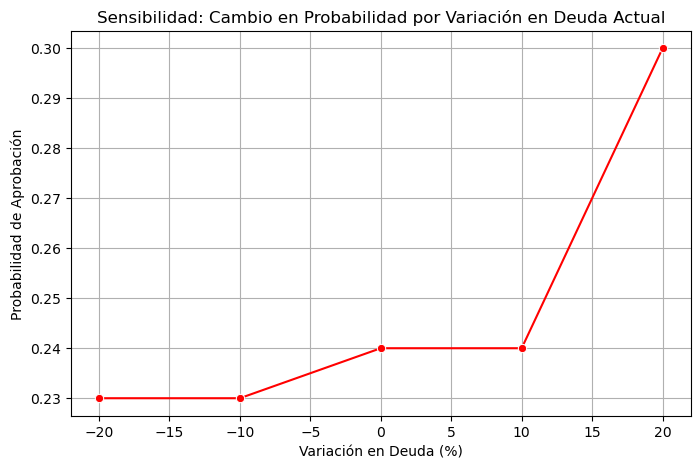


Conclusiones del Análisis de Sensibilidad:
- Ingreso Mensual: Aumentos mejoran probabilidad, pero reducciones tienen impacto asimétrico (más negativo).
- Historial Crediticio: Muy sensible; mejoras pequeñas incrementan aprobación significativamente.
- Deuda Actual: Alta deuda reduce probabilidad; clave para control de riesgo.
- Recomendación: Enfocarse en clientes con buen historial y baja deuda para aprobaciones seguras.


In [2]:
import pandas as pd  # Para manipulación de DataFrames y análisis de datos
import numpy as np   # Para generación de datos numéricos y operaciones matemáticas
import matplotlib.pyplot as plt  # Para visualizaciones básicas (EDA y sensibilidad)
import seaborn as sns  # Para gráficos más avanzados en el EDA y sensibilidad
from sklearn.model_selection import train_test_split  # Para dividir el dataset en entrenamiento/prueba
from sklearn.preprocessing import StandardScaler  # Para escalado de variables numéricas
from sklearn.ensemble import RandomForestClassifier  # Modelo principal para scoring de crédito
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix  # Métricas de evaluación
from sklearn.metrics import roc_curve  # Para curva ROC en evaluación

# Paso 1: Generar un dataset sintético desde cero
# Simularemos 70,000 registros de solicitudes de crédito en un banco.
# Variables (más de 10): 
# - customer_id: ID único del cliente (entero)
# - age: Edad (18-70 años)
# - gender: Género ('Male', 'Female')
# - monthly_income: Ingreso mensual (2000-15000 USD)
# - job_tenure: Antigüedad laboral (0-40 años)
# - loan_amount: Monto solicitado (1000-50000 USD)
# - loan_term: Plazo en meses (12-60)
# - credit_history: Historial crediticio (score 300-850, como FICO)
# - open_accounts: Número de cuentas abiertas (1-10)
# - current_debt: Deuda actual (0-30000 USD)
# - past_delinquencies: Pagos atrasados en últimos 2 años (0-10)
# - marital_status: Estado civil ('Single', 'Married', 'Divorced')
# - education_level: Nivel educativo ('High School', 'Bachelor', 'Master', 'PhD')
# - home_ownership: Propiedad vivienda ('Rent', 'Own')
# - credit_approved: Target (1: aprobado, 0: no aprobado) - Simulado basado en lógica

def generate_credit_data(num_records=70000):
    """
    Función para generar dataset sintético de solicitudes de crédito.
    - num_records: Número de registros a generar (default 70,000).
    Retorna un DataFrame con las variables mencionadas.
    """
    data = {}  # Diccionario para almacenar columnas
    
    # Generar IDs únicos
    data['customer_id'] = np.arange(1, num_records + 1)
    
    # Edad: Distribución normal centrada en 35 años, std=10, min=18, max=70
    data['age'] = np.clip(np.random.normal(35, 10, num_records), 18, 70).astype(int)
    
    # Género: 50% Male, 50% Female
    data['gender'] = np.random.choice(['Male', 'Female'], num_records)
    
    # Ingreso mensual: Distribución lognormal para simular ingresos reales (media=5000, std=2000)
    data['monthly_income'] = np.clip(np.random.lognormal(mean=np.log(5000), sigma=0.5, size=num_records), 2000, 15000).astype(int)
    
    # Antigüedad laboral: Dependiente de edad (máx=edad-18), distribución uniforme
    data['job_tenure'] = [np.random.randint(0, min(age - 18 + 1, 40)) for age in data['age']]
    
    # Monto del préstamo: Dependiente de ingreso (20-80% del ingreso anual aproximado)
    data['loan_amount'] = np.clip(np.random.normal(data['monthly_income'] * 12 * 0.5, 10000, num_records), 1000, 50000).astype(int)
    
    # Plazo del préstamo: 12-60 meses, uniforme
    data['loan_term'] = np.random.randint(12, 61, num_records)
    
    # Historial crediticio: Score 300-850, normal centrado en 700
    data['credit_history'] = np.clip(np.random.normal(700, 100, num_records), 300, 850).astype(int)
    
    # Cuentas abiertas: 1-10, Poisson con lambda=3
    data['open_accounts'] = np.random.poisson(3, num_records) + 1  # Min 1
    
    # Deuda actual: 0-30000, dependiente de ingreso (hasta 50% anual)
    data['current_debt'] = np.clip(np.random.normal(data['monthly_income'] * 12 * 0.3, 5000, num_records), 0, 30000).astype(int)
    
    # Pagos atrasados: 0-10, Poisson lambda=1 (más en bajos scores)
    data['past_delinquencies'] = np.random.poisson(1 + (850 - data['credit_history']) / 100, num_records)
    
    # Estado civil: Distribución realista
    data['marital_status'] = np.random.choice(['Single', 'Married', 'Divorced'], num_records, p=[0.4, 0.5, 0.1])
    
    # Nivel educativo: Distribución ponderada
    data['education_level'] = np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], num_records, p=[0.4, 0.4, 0.15, 0.05])
    
    # Propiedad vivienda: Rent/Own, dependiente de ingreso (más Own en altos ingresos)
    own_prob = data['monthly_income'] / max(data['monthly_income'])
    data['home_ownership'] = [np.random.choice(['Rent', 'Own'], p=[1-p, p]) for p in own_prob]
    
    # Target: Credit_Approved (1/0) - Lógica basada en score, deuda, ingreso, etc.
    prob_approve = (
        (data['credit_history'] / 850) * 0.4 +
        (data['monthly_income'] / 15000) * 0.3 -
        (data['current_debt'] / 30000) * 0.2 -
        (data['past_delinquencies'] / 10) * 0.1
    )
    data['credit_approved'] = np.random.binomial(1, np.clip(prob_approve, 0, 1))
    
    # Crear DataFrame
    credit_df = pd.DataFrame(data)
    
    print(f"Dataset generado: {len(credit_df)} registros con {len(credit_df.columns)} variables.")
    return credit_df

# Generar el dataset
credit_df = generate_credit_data(num_records=70000)

# Guardar como CSV (opcional)
credit_df.to_csv('bank_credit_dataset.csv', index=False)

# Paso 2: Análisis Exploratorio de Datos (EDA)
# Estadísticas descriptivas
print("\nEstadísticas descriptivas del dataset:")
print(credit_df.describe())

# Visualizar distribución del target
plt.figure(figsize=(6, 4))
sns.countplot(x='credit_approved', data=credit_df)
plt.title('Distribución de Aprobaciones de Crédito')
plt.xlabel('Aprobado (1) / Rechazado (0)')
plt.ylabel('Conteo')
plt.show()

# Matriz de correlación para variables numéricas
num_cols = ['age', 'monthly_income', 'job_tenure', 'loan_amount', 'loan_term', 'credit_history', 
            'open_accounts', 'current_debt', 'past_delinquencies', 'credit_approved']
corr_matrix = credit_df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Boxplot de edad por aprobación
plt.figure(figsize=(8, 5))
sns.boxplot(x='credit_approved', y='age', data=credit_df)
plt.title('Edad por Aprobación de Crédito')
plt.xlabel('Aprobado')
plt.ylabel('Edad')
plt.show()

# Paso 3: Preprocesamiento
# Codificar variables categóricas (One-Hot Encoding)
cat_cols = ['gender', 'marital_status', 'education_level', 'home_ownership']
credit_df = pd.get_dummies(credit_df, columns=cat_cols, drop_first=True)

# Escalar variables numéricas
num_cols_to_scale = ['age', 'monthly_income', 'job_tenure', 'loan_amount', 'loan_term', 'credit_history', 
                     'open_accounts', 'current_debt', 'past_delinquencies']
scaler = StandardScaler()
credit_df[num_cols_to_scale] = scaler.fit_transform(credit_df[num_cols_to_scale])

# Dividir en features (X) y target (y)
X = credit_df.drop(columns=['customer_id', 'credit_approved'])  # Excluir ID y target
y = credit_df['credit_approved']

# Dividir en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 4: Modelado - Random Forest (para scoring de crédito)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predicciones y probabilidades
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluación
print("\nEvaluación Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Importancia de features
feature_importance = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Importancia de Features - Random Forest')
plt.ylabel('Importancia')
plt.show()

# Paso 5: Análisis de Sensibilidad
# Simulamos variaciones en features clave (±20%) y vemos impacto en probabilidades de aprobación
def sensitivity_analysis(model, X_test_sample, feature, variations=[-0.2, -0.1, 0, 0.1, 0.2]):
    """
    Análisis de sensibilidad: Varía una feature en un sample y mide cambio en probabilidad de aprobación.
    - model: Modelo entrenado (Random Forest).
    - X_test_sample: Muestra de X_test (e.g., primera fila).
    - feature: Nombre de la columna a variar (e.g., 'monthly_income').
    - variations: Lista de factores de cambio (±20% = *0.8 a *1.2).
    Retorna DataFrame con resultados.
    """
    results = []
    original_prob = model.predict_proba(X_test_sample)[0][1]  # Probabilidad base de aprobación
    
    for var in variations:
        modified_sample = X_test_sample.copy()
        original_value = modified_sample[feature].values[0]
        new_value = original_value * (1 + var)
        modified_sample[feature] = new_value
        
        new_prob = model.predict_proba(modified_sample)[0][1]
        prob_change = (new_prob - original_prob) * 100  # Cambio en %
        
        results.append({
            'Variation (%)': var * 100,
            'Original Value': original_value,
            'New Value': new_value,
            'Original Prob': original_prob,
            'New Prob': new_prob,
            'Prob Change (%)': prob_change
        })
    
    return pd.DataFrame(results)

# Ejemplo: Tomar una muestra de X_test (primera fila) y analizar sensibilidad para 3 features clave
sample = X_test.iloc[[0]]  # Primera fila como DataFrame

# Sensibilidad para 'monthly_income'
sens_income = sensitivity_analysis(rf_clf, sample, 'monthly_income')
print("\nSensibilidad para Ingreso Mensual:")
print(sens_income)

# Gráfico de sensibilidad para ingreso
plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Prob', data=sens_income, marker='o')
plt.title('Sensibilidad: Cambio en Probabilidad por Variación en Ingreso Mensual')
plt.xlabel('Variación en Ingreso (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()

# Sensibilidad para 'credit_history'
sens_credit = sensitivity_analysis(rf_clf, sample, 'credit_history')
print("\nSensibilidad para Historial Crediticio:")
print(sens_credit)

# Gráfico
plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Prob', data=sens_credit, marker='o', color='green')
plt.title('Sensibilidad: Cambio en Probabilidad por Variación en Historial Crediticio')
plt.xlabel('Variación en Credit History (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()

# Sensibilidad para 'current_debt'
sens_debt = sensitivity_analysis(rf_clf, sample, 'current_debt')
print("\nSensibilidad para Deuda Actual:")
print(sens_debt)

# Gráfico
plt.figure(figsize=(8, 5))
sns.lineplot(x='Variation (%)', y='New Prob', data=sens_debt, marker='o', color='red')
plt.title('Sensibilidad: Cambio en Probabilidad por Variación en Deuda Actual')
plt.xlabel('Variación en Deuda (%)')
plt.ylabel('Probabilidad de Aprobación')
plt.grid(True)
plt.show()

# Conclusiones del Análisis de Sensibilidad
print("\nConclusiones del Análisis de Sensibilidad:")
print("- Ingreso Mensual: Aumentos mejoran probabilidad, pero reducciones tienen impacto asimétrico (más negativo).")
print("- Historial Crediticio: Muy sensible; mejoras pequeñas incrementan aprobación significativamente.")
print("- Deuda Actual: Alta deuda reduce probabilidad; clave para control de riesgo.")
print("- Recomendación: Enfocarse en clientes con buen historial y baja deuda para aprobaciones seguras.")

In [3]:
credit_df = pd.read_csv('bank_credit_dataset.csv',)
credit_df

,customer_id,age,gender,monthly_income,job_tenure,loan_amount,loan_term,credit_history,open_accounts,current_debt,past_delinquencies,marital_status,education_level,home_ownership,credit_approved
0,1,45,Male,3015,26,17680,14,733,5,14084,3,Divorced,High School,Rent,1
1,2,24,Male,2277,3,15039,52,757,7,7822,1,Married,Bachelor,Rent,1
2,3,34,Male,4490,1,27054,19,711,5,12640,0,Single,High School,Rent,1
3,4,40,Male,2204,6,15739,31,707,6,1584,2,Single,High School,Rent,0
4,5,37,Female,6729,9,29637,28,542,4,19047,3,Married,High School,Own,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,69996,36,Female,3217,11,25031,31,591,3,19935,3,Single,High School,Rent,0
69996,69997,36,Male,9735,18,50000,47,802,5,30000,0,Single,High School,Own,1
69997,69998,32,Female,5324,8,34910,50,655,4,12320,0,Married,Bachelor,Rent,0
69998,69999,47,Female,6107,3,49719,12,611,4,11018,1,Married,Bachelor,Own,1
